### Here we go over some examples of the general capabilities related to the usage of Sandy and FRENDY with WINDIGO ###

Let's first go over functionality related to Sandy.

In [ ]:
# Import WINDIGO and other useful modules
import os
import numpy as np
import WINDIGO

Depending on how your virtual environment is set up, you may get issues with Sandy not being able to access your NJOY installation when using Jupyter notebooks. This can be fixed using the following line with the NJOY executable path replaced by that used for your specific installation:

In [14]:
os.environ["NJOY"] = "/home/jacob/miniconda3/envs/openmc-env/bin/njoy"

Let's retrieve some covariance matrices using Sandy. For this case, we will assume that we are investigating Be9's elastic scattering cross section data. We will use the CASMO12 energy grid given here: https://serpent.vtt.fi/mediawiki/index.php/CASMO_12-group_structure


 njoy 2016.78  03Feb25                                       04/05/26 18:34:41
 *****************************************************************************

 moder...                                                                 0.0s

 reconr...                                                                0.0s

 broadr...                                                                0.0s

 thermr...                                                                0.0s

 wrote thermal data for temp = 5.0000E+02                                 0.1s

 heatr...                                                                 0.1s

 heatr...                                                                 0.1s

 gaspr...                                                                 0.1s

 purr...                                                                  0.1s

 mat =  425                                                               0.1s

 ---message from purr---mat  425 has no 

('covarianceMatrix_13Groups_Be9_MT_2_Relative.csv',
 'covariancePlot_13Groups_Be9MT2_Relative.png')

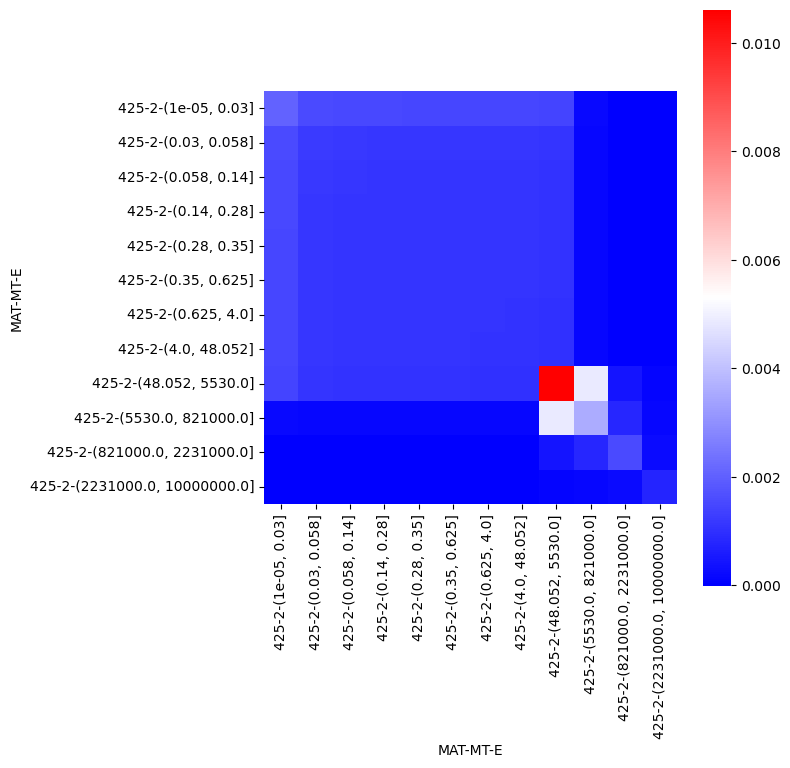

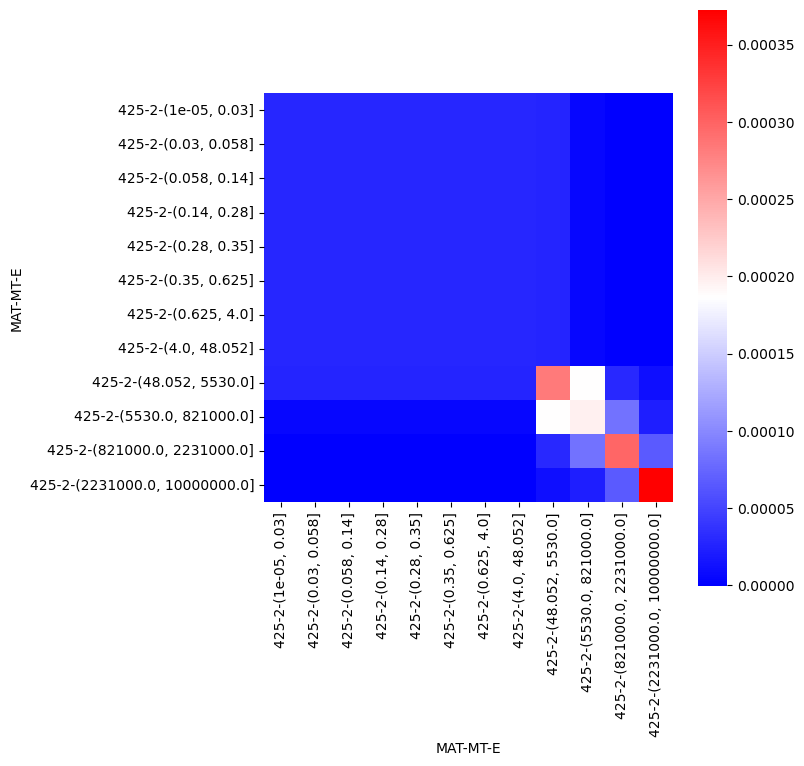

In [ ]:
# Specify the energy grid (MeV) for covariance data retrieval
energy_grid_CASMO_MeV = np.array([
    1.0e-11, 3.0e-8, 5.8e-8, 1.4e-7, 2.8e-7, 3.5e-7,
    6.25e-7, 4.0e-6, 4.8052e-5, 5.53e-3, 8.21e-1,
    2.231e0, 1.0e1
])

# Convert the energy grid from MeV to eV for Sandy
energy_grid_CASMO_eV = energy_grid_CASMO_MeV * 10**6

# Retrieve the absolute covariance matrix using Sandy.
# Absolute covariance is required for uncertainty quantification
# via the direct perturbation methodology, but not for cross
# section generation.
WINDIGO.sandy_covariance_retrieval(
    energy_grid=energy_grid_CASMO_eV,
    nuclide="Be9",
    mt_Number=2,
    data_library="endfb_80",
    temperature=500,
    relative_Flag=False,
    plotting_Flag=True
)

# Retrieve the relative covariance matrix using Sandy.
# This will be used to generate cross sections with randomly
# sampled perturbation coefficients.
WINDIGO.sandy_covariance_retrieval(
    energy_grid=energy_grid_CASMO_eV,
    nuclide="Be9",
    mt_Number=2,
    data_library="endfb_80",
    temperature=500,
    relative_Flag=True,
    plotting_Flag=True
)

Retrieving covariance matrices is the primary functionality of Sandy that WINDIGO is designed to interface with. Other Sandy functionality has not been incorporated into WINDIGO at this time.

Let's move onto some of the FRENDY functionality. In order to create perturbed cross section files, we first need a base unperturbed ACE file. We will continue using Be9 as our example. We will also use the CASMO12 energy grid to upgrade our base ACE file by adding additional energy grid points to better ensure cross section perturbations are applied properly

In [ ]:
# Generate an upgraded unperturbed Be-9 ACE file
unperturbed_be_ace_path = WINDIGO.generate_unperturbed_neutron_ace_file(
    frendy_Path="/mnt/c/Users/jacob/frendy_20241030",
    endf_Path=(
        "/mnt/c/Users/jacob/frendy_20241030/ENDF-B-VIII.0"
        "/ENDF-B-VIII.0/neutrons/n-004_Be_009.endf"
    ),
    temperature=500,
    nuclide="Be9",
    upgrade_Flag=True,
    energy_grid=energy_grid_CASMO_eV,
    cleanup_Flag=True
)

The path to the ace file generation input is: /mnt/c/Users/jacob/frendy_20241030/frendy/main/Be9_acegenerator_upgrade.dat


/////////////////////////////////////////////////////////////////////////////////////////
//                                                                                     //
//  //////////  ///////////    //////////  /////      ///  /////////    ///       ///  //
//  ///         ///      ///   ///         //////     ///  ///     ///   ///     ///   //
//  ///         ///      ///   ///         /// ///    ///  ///      ///   ///   ///    //
//  //////////  ///////////    //////////  ///  ///   ///  ///       ///   ///////     //
//  ///         ///    ///     ///         ///   ///  ///  ///       ///     ///       //
//  ///         ///     ///    ///         ///    /// ///  ///      ///      ///       //
//  ///         ///      ///   ///         ///     //////  ///     ///       ///       //
//  ///         ///       ///  //////////  ///      /////  ///////

Now that we have our unperturbed ACE file we can begin applying perturbations to it. We will first generate ACE files that have been directly perturbed, meaning that over specified energy ranges a cross section of interest is multipled by a chosen constant.

For our purposes, we will use the CASMO12 energy grid to define our perturbation bounds, and we will perturb the elastic scattering cross section.

IMPORTANT: FRENDY is not consistent in the units that it requires for energy inputs. Generating unperturbed ACE files uses eV, while generating perturbed ACE files uses MeV. Keep this in mind when performing your own nuclear data investigations.

In [ ]:
# Create direct perturbation ACE files
be_direct_perturbation_ace_files_path = (
    WINDIGO.generate_direct_perturbation_ace_files(
        frendy_Path="/mnt/c/Users/jacob/frendy_20241030",
        unperturbed_ACE_file_path=unperturbed_be_ace_path,
        energy_grid=energy_grid_CASMO_MeV,
        mt_Number=2,
        nuclide="Be9",
        perturbation_coefficient=1.05,  # Impose a positive 5% perturbation
        cleanup_Flag=True
    )
)

Intermediate Files Removed
All ACE files have successfully generated; they are located in: /mnt/c/Users/jacob/frendy_20241030/Be9_DirectPerturbationACEFiles_ReactionMT_2


We can now use these directly perturbed ACE files to help construct sensitivity plots and perform uncertainty quantification for a model of interest. We will save how to perform that for a later example.

To end off this showcase of general functionality, we will now generate some ACE files using randomly sampled perturbation coefficients. This will make use of the relative covariance matrix that we retrieved using Sandy earlier. Similarly to the direct perturbations, we will use the CASMO12 energy grid and perturb the elastic scattering cross section.

In [16]:
# Create random sampling ACE files
be_random_sampling_ace_files = (
    WINDIGO.generate_random_sampling_ace_files(
        frendy_Path="/mnt/c/Users/jacob/frendy_20241030",
        unperturbed_ACE_file_path=unperturbed_be_ace_path,
        relative_covariance_matrix_path=(
            "covarianceMatrix_13Groups_Be9_MT_2_Relative.csv"
        ),
        energy_grid=energy_grid_CASMO_MeV,
        mt_Number=2,
        nuclide="Be9",
        sample_size=100,
        cleanup_Flag=False
    )
)

Perturbation factors created successfully
All ACE files generated successfully and are located in: /mnt/c/Users/jacob/frendy_20241030/Be9_RandomSamplingACEFiles_ReactionMT_2


We now have all of the perturbed ACE files needed to perform uncertainty quantification using two methods for a model based on Be-9's elastic scattering cross section at 500 K. The means by which these files are used to do so is presented in other examples.